### Emotion & sentiment analysis V1

In [24]:
import os
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

DATASET_DIR = "my_dataset"

csv_files = glob.glob(os.path.join(DATASET_DIR, "*.csv"))
csv_files

datasets = []

for file_path in csv_files:
    file_name = os.path.basename(file_path)
    
    portal = file_name.split("_")[0]
    content_type = "article" if "articles" in file_name else "comment"
    
    df = pd.read_csv(file_path)
    df["portal"] = portal
    df["content_type"] = content_type
    df["source_file"] = file_name
    
    datasets.append(df)

data = pd.concat(datasets, ignore_index=True)
print(data.shape)
data.head()

def detect_text_column(df):
    candidates = ["text", "content", "comment", "body", "message", "title"]
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError("No text column found")

text_column = detect_text_column(data)
text_column

data["text"] = (
    data[text_column]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

data = data[data["text"].str.len() > 10].reset_index(drop=True)
print(len(data))

# Load Sentiment Model
sentiment_model = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=sentiment_model,
    tokenizer=sentiment_model,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=512
)

# Load Emotion Model
emotion_model = "j-hartmann/emotion-english-distilroberta-base"

emotion_pipeline = pipeline(
    "text-classification",
    model=emotion_model,
    tokenizer=emotion_model,
    return_all_scores=True,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=512
)

# Sentiment inference (batched)
def run_sentiment(texts, batch_size=32):
    results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size].tolist()
        out = sentiment_pipeline(batch)
        results.extend(out)
    return results

sentiment_results = run_sentiment(data["text"])

# Store sentiment results
data["sentiment_label"] = [r["label"] for r in sentiment_results]
data["sentiment_score"] = [r["score"] for r in sentiment_results]

data[["sentiment_label", "sentiment_score"]].value_counts()

# Emotion inference (batched)
def run_emotions(texts, batch_size=16):
    all_results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size].tolist()
        outputs = emotion_pipeline(batch)
        all_results.extend(outputs)
    return all_results

emotion_results = run_emotions(data["text"])

# Convert emotion scores to columns
emotion_labels = [e["label"] for e in emotion_results[0]]

for label in emotion_labels:
    data[f"emotion_{label}"] = [
        next(e["score"] for e in emotions if e["label"] == label)
        for emotions in emotion_results
    ]

data["dominant_emotion"] = data[
    [f"emotion_{l}" for l in emotion_labels]
].idxmax(axis=1).str.replace("emotion_", "")

data[["dominant_emotion"]].value_counts()

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: c51c9092-ff37-4057-8867-dd7b35113021)')' thrown while requesting HEAD https://huggingface.co/cardiffnlp/twitter-xlm-roberta-base-sentiment/resolve/main/config.json
Retrying in 1s [Retry 1/5].


(279, 19)
260


Device set to use cpu
Device set to use cpu
C:\anaconda3\envs\sound\lib\site-packages\transformers\pipelines\text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
 11%|███████████▌                                                                                            | 1/9 [00:01<00:15,  1.95s/it]


KeyboardInterrupt: 

### Emotion Shift & Divergence Metrics

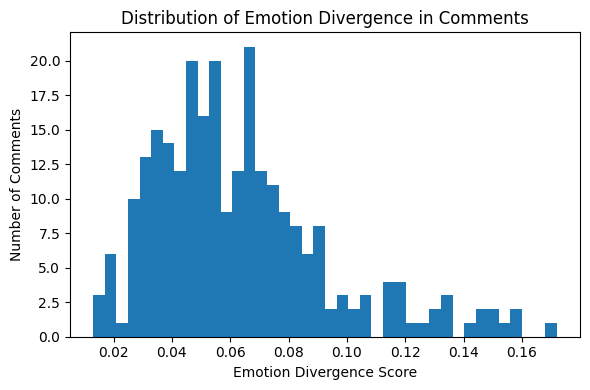

<Figure size 800x400 with 0 Axes>

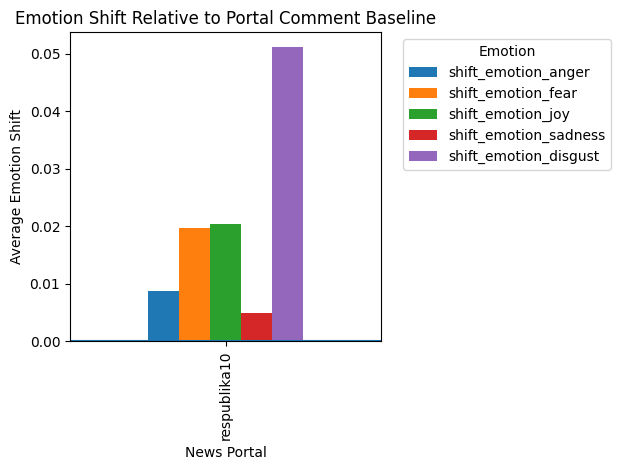

In [35]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Work ONLY with comments (robust baseline)
# --------------------------------------------------
comments = data[data["content_type"] == "comment"].copy()

emotion_cols = [
    "emotion_anger",
    "emotion_fear",
    "emotion_joy",
    "emotion_sadness",
    "emotion_disgust"
]

# --------------------------------------------------
# 2. Portal-level COMMENT baseline (median = robust)
# --------------------------------------------------
portal_comment_baseline = (
    comments
    .groupby("portal")[emotion_cols]
    .median()
)

# --------------------------------------------------
# 3. Emotion shift relative to portal baseline
# --------------------------------------------------
for emo in emotion_cols:
    comments[f"shift_{emo}"] = (
        comments[emo] -
        comments["portal"].map(portal_comment_baseline[emo])
    )

# --------------------------------------------------
# 4. Emotion divergence score (finite by construction)
# --------------------------------------------------
comments["emotion_divergence"] = comments[
    [f"shift_{e}" for e in emotion_cols]
].abs().mean(axis=1)

# --------------------------------------------------
# 5. Plot: Emotion divergence distribution
# --------------------------------------------------
plt.figure(figsize=(6,4))
plt.hist(
    comments["emotion_divergence"],
    bins=40
)
plt.xlabel("Emotion Divergence Score")
plt.ylabel("Number of Comments")
plt.title("Distribution of Emotion Divergence in Comments")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6. Plot: Average emotion shift per portal
# --------------------------------------------------
shift_summary = (
    comments
    .groupby("portal")[[f"shift_{e}" for e in emotion_cols]]
    .mean()
)

plt.figure(figsize=(8,4))
shift_summary.plot(kind="bar")
plt.axhline(0)
plt.xlabel("News Portal")
plt.ylabel("Average Emotion Shift")
plt.title("Emotion Shift Relative to Portal Comment Baseline")
plt.legend(title="Emotion", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### Statistical Validation of Emotion Shifts

In [23]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, kruskal

# --------------------------------------------------
# Configuration
# --------------------------------------------------
emotion_cols = [
    "emotion_anger",
    "emotion_fear",
    "emotion_joy",
    "emotion_sadness",
    "emotion_disgust"
]

shift_cols = [f"shift_{e}" for e in emotion_cols]
portals = comments["portal"].unique()

results = []

# --------------------------------------------------
# 1. Within-portal significance (Wilcoxon test)
#    H0: median emotion shift == 0
# --------------------------------------------------
for portal in portals:
    subset = comments[comments["portal"] == portal]
    
    for emo, shift_col in zip(emotion_cols, shift_cols):
        values = subset[shift_col].dropna()
        
        # Wilcoxon requires non-zero variance
        if len(values) < 20 or values.std() == 0:
            continue
        
        stat, p_value = wilcoxon(values)
        
        results.append({
            "portal": portal,
            "emotion": emo.replace("emotion_", ""),
            "test": "Wilcoxon (shift ≠ 0)",
            "n": len(values),
            "median_shift": values.median(),
            "p_value": p_value
        })

wilcoxon_results = pd.DataFrame(results)

# --------------------------------------------------
# 2. Between-portal comparison (Kruskal–Wallis)
#    H0: same distribution across portals
# --------------------------------------------------
kw_results = []

for emo, shift_col in zip(emotion_cols, shift_cols):
    groups = [
        comments[comments["portal"] == p][shift_col].dropna()
        for p in portals
        if len(comments[comments["portal"] == p][shift_col].dropna()) > 20
    ]
    
    if len(groups) < 2:
        continue
    
    stat, p_value = kruskal(*groups)
    
    kw_results.append({
        "emotion": emo.replace("emotion_", ""),
        "test": "Kruskal–Wallis (between portals)",
        "p_value": p_value
    })

kruskal_results = pd.DataFrame(kw_results)

# --------------------------------------------------
# 3. Effect size: Cliff's Delta (pairwise portals)
# --------------------------------------------------
def cliffs_delta(x, y):
    x = np.array(x)
    y = np.array(y)
    n = len(x) * len(y)
    if n == 0:
        return np.nan
    return (np.sum(x[:, None] > y) - np.sum(x[:, None] < y)) / n

effect_sizes = []

for emo, shift_col in zip(emotion_cols, shift_cols):
    for i, p1 in enumerate(portals):
        for p2 in portals[i+1:]:
            x = comments[comments["portal"] == p1][shift_col].dropna()
            y = comments[comments["portal"] == p2][shift_col].dropna()
            
            if len(x) < 20 or len(y) < 20:
                continue
            
            delta = cliffs_delta(x, y)
            
            effect_sizes.append({
                "emotion": emo.replace("emotion_", ""),
                "portal_1": p1,
                "portal_2": p2,
                "cliffs_delta": delta
            })

effect_size_results = pd.DataFrame(effect_sizes)

# --------------------------------------------------
# 4. Output summary tables
# --------------------------------------------------
print("\n=== Within-Portal Emotion Shift Significance ===")
if not wilcoxon_results.empty:
    display(wilcoxon_results.sort_values("p_value"))
else:
    print("No valid Wilcoxon tests (insufficient variance or sample size).")

print("\n=== Between-Portal Differences ===")
if not kruskal_results.empty and "p_value" in kruskal_results.columns:
    display(kruskal_results.sort_values("p_value"))
else:
    print("Kruskal–Wallis test not applicable (insufficient comparable groups).")

print("\n=== Effect Sizes (Cliff's Delta) ===")
if not effect_size_results.empty:
    display(
        effect_size_results
        .assign(abs_delta=lambda x: x["cliffs_delta"].abs())
        .sort_values("abs_delta", ascending=False)
        .drop(columns="abs_delta")
    )
else:
    print("No effect sizes computed (insufficient pairwise data).")


=== Within-Portal Emotion Shift Significance ===


,portal,emotion,test,n,median_shift,p_value
4,respublika10,disgust,Wilcoxon (shift ≠ 0),260,0.0,0.000013
2,respublika10,joy,Wilcoxon (shift ≠ 0),260,0.0,0.079908
0,respublika10,anger,Wilcoxon (shift ≠ 0),260,0.0,0.228215
1,respublika10,fear,Wilcoxon (shift ≠ 0),260,0.0,0.323015
3,respublika10,sadness,Wilcoxon (shift ≠ 0),260,0.0,0.856487



=== Between-Portal Differences ===
Kruskal–Wallis test not applicable (insufficient comparable groups).

=== Effect Sizes (Cliff's Delta) ===
No effect sizes computed (insufficient pairwise data).


### Unified Influence Alert Score

In [12]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# Assumptions:
# comments DataFrame exists
# Columns exist:
#   - emotion_divergence
#   - sentiment_label, sentiment_score
#   - text (for embeddings if needed later)
# --------------------------------------------------

# --------------------------------------------------
# 1. Normalize components (robust z-score)
# --------------------------------------------------
def robust_z(series):
    median = series.median()
    mad = np.median(np.abs(series - median))
    if mad == 0:
        return pd.Series(0, index=series.index)
    return (series - median) / (1.4826 * mad)

# --------------------------------------------------
# 2. Emotion component (already computed)
# --------------------------------------------------
comments["emotion_component"] = robust_z(
    comments["emotion_divergence"]
)

# --------------------------------------------------
# 3. Sentiment component
#    Focus on NEGATIVE sentiment amplification
# --------------------------------------------------
comments["sentiment_numeric"] = comments["sentiment_label"].map({
    "negative": 1.0,
    "neutral": 0.0,
    "positive": -1.0
})

comments["sentiment_component"] = robust_z(
    comments["sentiment_numeric"] * comments["sentiment_score"]
)

# --------------------------------------------------
# 4. Semantic deviation component
#    If semantic similarity exists, invert it
# --------------------------------------------------
if "semantic_similarity" in comments.columns:
    comments["semantic_component"] = robust_z(
        1.0 - comments["semantic_similarity"]
    )
else:
    # Fallback: no semantic signal available
    comments["semantic_component"] = 0.0

# --------------------------------------------------
# 5. Unified Alert Score (weighted fusion)
#    Weights reflect influence theory:
#    emotion > semantics > sentiment
# --------------------------------------------------
comments["alert_score"] = (
    0.5 * comments["emotion_component"] +
    0.3 * comments["semantic_component"] +
    0.2 * comments["sentiment_component"]
)

# --------------------------------------------------
# 6. Normalize final alert score
# --------------------------------------------------
comments["alert_score_norm"] = robust_z(
    comments["alert_score"]
)

# --------------------------------------------------
# 7. Binary influence alert
#    Threshold = strong outliers
# --------------------------------------------------
ALERT_THRESHOLD = 3.0

comments["influence_alert"] = (
    comments["alert_score_norm"] > ALERT_THRESHOLD
)

# --------------------------------------------------
# 8. Sanity checks & summary
# --------------------------------------------------
print("Alert rate:", comments["influence_alert"].mean())
print("\nTop alerts:")
display(
    comments
    .sort_values("alert_score_norm", ascending=False)
    .head(10)[
        [
            "portal",
            "alert_score_norm",
            "emotion_divergence",
            "sentiment_label",
            "sentiment_score"
        ]
    ]
)

Alert rate: 0.024915824915824916

Top alerts:


,portal,alert_score_norm,emotion_divergence,sentiment_label,sentiment_score
306,15min,6.905811,0.241579,negative,0.960987
635,15min,5.717127,0.209453,negative,0.873225
346,15min,5.433837,0.201659,negative,0.855789
258,15min,5.356206,0.211994,negative,0.535595
492,15min,5.347103,0.211606,negative,0.538508
689,15min,5.346825,0.196224,negative,0.927369
755,15min,5.025084,0.186057,negative,0.940825
986,15min,4.941477,0.183907,negative,0.931889
379,15min,4.479351,0.189191,negative,0.448211
996,15min,4.162945,0.167091,negative,0.767554


### New next day

In [28]:
import os
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm

import torch
from transformers import pipeline

DATASET_DIR = "my_dataset"
MAX_CHARS = 1500

csv_files = glob.glob(os.path.join(DATASET_DIR, "*.csv"))

# --------------------------------------------------
# TEXT COLUMN DETECTION PER FILE
# --------------------------------------------------
def detect_text_column(df, content_type):
    if content_type == "article":
        candidates = ["article_content", "content", "body", "text", "title"]
    else:
        candidates = ["comment", "text", "message", "body"]
        
    for col in candidates:
        if col in df.columns:
            return col
    return None

datasets = []

# --------------------------------------------------
# LOAD CSVs PROPERLY
# --------------------------------------------------
for file_path in csv_files:
    file_name = os.path.basename(file_path)
    
    portal = file_name.split("_")[0]
    content_type = "article" if "articles" in file_name else "comment"
    
    df = pd.read_csv(file_path)
    
    text_col = detect_text_column(df, content_type)
    if text_col is None:
        print("No usable text column in:", file_name)
        continue
    
    # Build unified text field
    if content_type == "article":
        # Combine title + article body if available
        title = df["title"].fillna("") if "title" in df.columns else ""
        body = df[text_col].fillna("")
        df["text"] = (title.astype(str) + " " + body.astype(str))
    else:
        df["text"] = df[text_col].astype(str)
    
    # Clean text
    df["text"] = (
        df["text"]
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .str.slice(0, MAX_CHARS)
    )
    
    # Add metadata
    df["portal"] = portal
    df["content_type"] = content_type
    df["source_file"] = file_name
    
    # Remove empty texts
    df = df[df["text"].str.len() > 10]
    
    datasets.append(df)

# --------------------------------------------------
# CONCAT ALL DATA
# --------------------------------------------------
data = pd.concat(datasets, ignore_index=True)

print("Total rows:", len(data))
print(data.groupby("content_type").size())
print("Columns:", data.columns.tolist())

assert len(data) > 0
assert "article" in data["content_type"].values
assert "comment" in data["content_type"].values

# --------------------------------------------------
# LOAD MODELS
# --------------------------------------------------
sentiment_model = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
emotion_model = "j-hartmann/emotion-english-distilroberta-base"

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=sentiment_model,
    tokenizer=sentiment_model,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=512
)

emotion_pipeline = pipeline(
    "text-classification",
    model=emotion_model,
    tokenizer=emotion_model,
    return_all_scores=True,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=512
)

# --------------------------------------------------
# SENTIMENT INFERENCE
# --------------------------------------------------
def run_sentiment(texts, batch_size=32):
    results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size].tolist()
        batch = [t[:MAX_CHARS] for t in batch]
        out = sentiment_pipeline(batch)
        results.extend(out)
    return results

sentiment_results = run_sentiment(data["text"])

data["sentiment_label"] = [r["label"] for r in sentiment_results]
data["sentiment_score"] = [r["score"] for r in sentiment_results]

print(data[["sentiment_label", "sentiment_score"]].value_counts().head())

# --------------------------------------------------
# EMOTION INFERENCE
# --------------------------------------------------
def run_emotions(texts, batch_size=16):
    all_results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size].tolist()
        batch = [t[:MAX_CHARS] for t in batch]
        outputs = emotion_pipeline(batch)
        all_results.extend(outputs)
    return all_results

emotion_results = run_emotions(data["text"])

emotion_labels = [e["label"] for e in emotion_results[0]]

for label in emotion_labels:
    data[f"emotion_{label}"] = [
        next(e["score"] for e in emotions if e["label"] == label)
        for emotions in emotion_results
    ]

data["dominant_emotion"] = data[
    [f"emotion_{l}" for l in emotion_labels]
].idxmax(axis=1).str.replace("emotion_", "")

print(data["dominant_emotion"].value_counts())

Total rows: 270
content_type
article     10
comment    260
dtype: int64
Columns: ['article_id', 'url', 'title', 'published_at', 'category', 'keywords', 'comments_count', 'article_content', 'text', 'portal', 'content_type', 'source_file', 'comment_id', 'username', 'comment', 'created_at', 'is_reply', 'parent_ref', 'reactions_dislike', 'reactions_like']


Device set to use cpu
Device set to use cpu
C:\anaconda3\envs\sound\lib\site-packages\transformers\pipelines\text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:16<00:00,  1.79s/it]


sentiment_label  sentiment_score
negative         0.826027           2
                 0.349348           1
neutral          0.381397           1
                 0.376765           1
                 0.374994           1
Name: count, dtype: int64


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:11<00:00,  1.52it/s]

dominant_emotion
neutral     175
fear         37
disgust      29
surprise     12
joy          11
sadness       4
anger         2
Name: count, dtype: int64


Articles: 10
Comments: 260
Emotion columns: ['emotion_anger', 'emotion_disgust', 'emotion_fear', 'emotion_joy', 'emotion_neutral', 'emotion_sadness', 'emotion_surprise']
Article baselines: 10
Comments before drop: 260
Comments after drop: 260


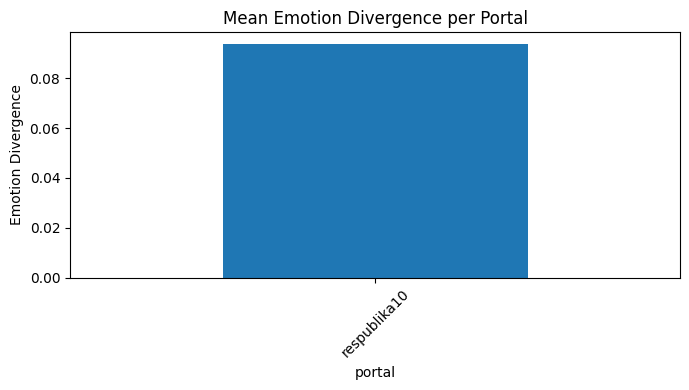

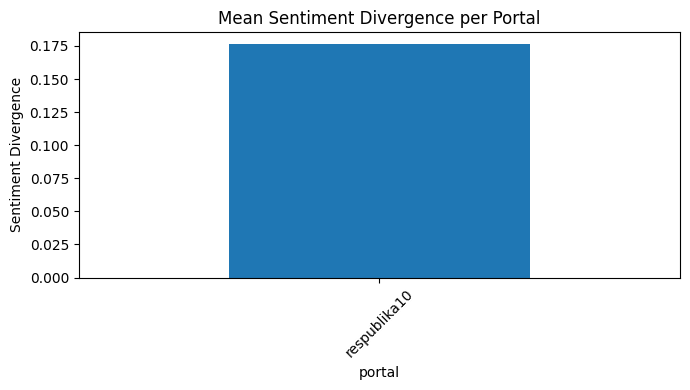

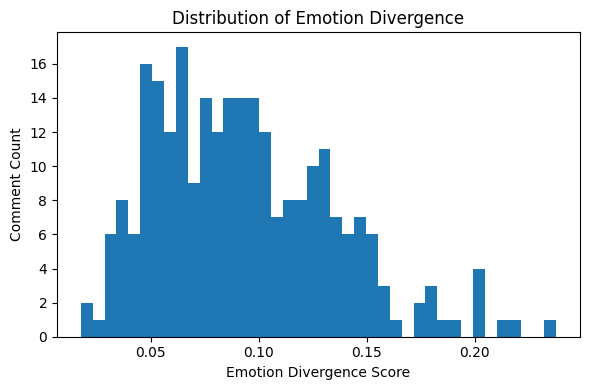


Top 10 Emotion Divergence Articles:
article_id
87235745    0.125927
87236589    0.118917
87237432    0.117626
87237401    0.097098
87237568    0.094536
87237443    0.093216
87237371    0.086347
87237127    0.083027
87237265    0.074267
87236417    0.069403
Name: emotion_divergence, dtype: float64

Top Article Titles:
  article_id                                              title
0   87236589  Tai bent kvapelis! Aromatingiausi pasaulio sūriai
1   87236417  Amerikiečių reportažas apie „Ukrainos Veneciją...
2   87235745  Miestai, kurie išties veda iš proto: apie psic...
3   87237401                    Karalienės burtažodžių paveikti
4   87237265                             Pedagogika pagal kinus
5   87237127  Dažnas vairuotojas pamiršta svarbias taisykles...
6   87237432     Neklauskit dainiaus vardo, arba „Nuogas ruduo“
7   87237371  Olava STRIKULIENĖ: Lietuvos balioninė politika...
8   87237568  Omega riebalų rūgštys: kodėl jos svarbios ir k...
9   87237443  Šilkinis tualetinis popier

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Split articles and comments
# --------------------------------------------------
articles = data[data["content_type"] == "article"].copy()
comments = data[data["content_type"] == "comment"].copy()

print("Articles:", len(articles))
print("Comments:", len(comments))

# Normalize IDs (critical safety)
articles["article_id"] = articles["article_id"].astype(str).str.strip()
comments["article_id"] = comments["article_id"].astype(str).str.strip()

# --------------------------------------------------
# 2. Emotion columns
# --------------------------------------------------
emotion_cols = [c for c in data.columns if c.startswith("emotion_")]
print("Emotion columns:", emotion_cols)

# --------------------------------------------------
# 3. Article emotion baseline
# --------------------------------------------------
article_emotions = (
    articles
    .groupby("article_id")[emotion_cols]
    .mean()
    .reset_index()
)

article_sentiment = (
    articles
    .groupby("article_id")["sentiment_score"]
    .mean()
    .reset_index()
    .rename(columns={"sentiment_score": "article_sentiment"})
)

article_baseline = article_emotions.merge(article_sentiment, on="article_id")

print("Article baselines:", len(article_baseline))

# --------------------------------------------------
# 4. Merge baseline into comments
# --------------------------------------------------
comments = comments.merge(
    article_baseline,
    on="article_id",
    how="left",
    suffixes=("", "_article")
)

print("Comments before drop:", len(comments))
comments = comments.dropna(subset=[f"{emotion_cols[0]}_article"])
print("Comments after drop:", len(comments))

# --------------------------------------------------
# 5. Emotion divergence per comment
# --------------------------------------------------
for e in emotion_cols:
    comments[f"shift_{e}"] = comments[e] - comments[f"{e}_article"]

comments["emotion_divergence"] = comments[
    [f"shift_{e}" for e in emotion_cols]
].abs().mean(axis=1)

# --------------------------------------------------
# 6. Sentiment divergence
# --------------------------------------------------
comments["sentiment_divergence"] = (
    comments["sentiment_score"] - comments["article_sentiment"]
).abs()

# --------------------------------------------------
# 7. Portal aggregation
# --------------------------------------------------
portal_emotion = comments.groupby("portal")["emotion_divergence"].mean()
portal_sentiment = comments.groupby("portal")["sentiment_divergence"].mean()

# --------------------------------------------------
# 8. PLOTS
# --------------------------------------------------

# Emotion divergence by portal
plt.figure(figsize=(7,4))
portal_emotion.sort_values().plot(kind="bar")
plt.title("Mean Emotion Divergence per Portal")
plt.ylabel("Emotion Divergence")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sentiment divergence by portal
plt.figure(figsize=(7,4))
portal_sentiment.sort_values().plot(kind="bar")
plt.title("Mean Sentiment Divergence per Portal")
plt.ylabel("Sentiment Divergence")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Divergence distribution
plt.figure(figsize=(6,4))
plt.hist(comments["emotion_divergence"], bins=40)
plt.title("Distribution of Emotion Divergence")
plt.xlabel("Emotion Divergence Score")
plt.ylabel("Comment Count")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 9. Article-level extremes (case studies)
# --------------------------------------------------
article_extreme = (
    comments
    .groupby("article_id")["emotion_divergence"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Emotion Divergence Articles:")
print(article_extreme)

# Optional: attach titles if present
if "title" in articles.columns:
    top_with_titles = articles[
        articles["article_id"].isin(article_extreme.index)
    ][["article_id","title"]].drop_duplicates()
    print("\nTop Article Titles:")
    print(top_with_titles)


Comments: 260
Portal baselines:
         portal  emotion_anger  emotion_disgust  emotion_fear  emotion_joy  \
0  respublika10        0.07078         0.110895      0.135323      0.09952   

   emotion_neutral  emotion_sadness  emotion_surprise  
0         0.382776         0.101021          0.099684  


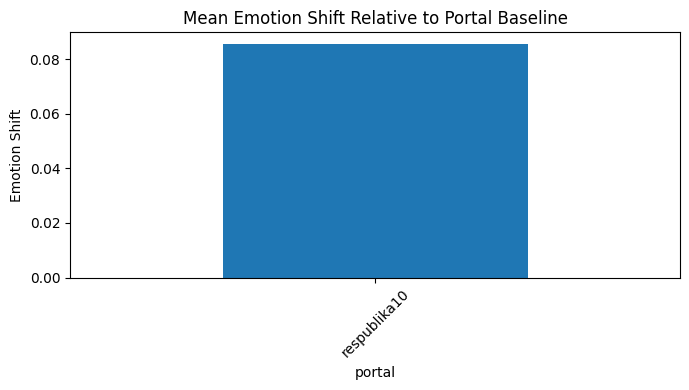

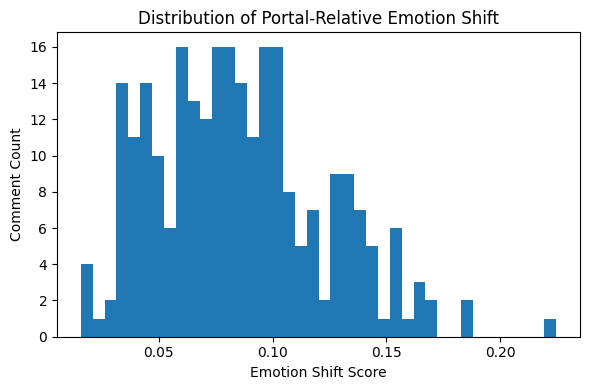


Top Articles Deviating from Portal Baseline:
article_id
87237443    0.098336
87237401    0.094586
87236589    0.090419
87237432    0.089570
87237568    0.089290
87235745    0.087514
87237371    0.079546
87237127    0.079493
87237265    0.074185
87236417    0.069524
Name: portal_emotion_shift, dtype: float64


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Only comments
# --------------------------------------------------
comments = data[data["content_type"] == "comment"].copy()
print("Comments:", len(comments))

emotion_cols = [c for c in data.columns if c.startswith("emotion_")]

# --------------------------------------------------
# 2. Portal emotion baseline (mean comment emotion)
# --------------------------------------------------
portal_baseline = (
    comments
    .groupby("portal")[emotion_cols]
    .mean()
    .reset_index()
)

print("Portal baselines:")
print(portal_baseline)

# --------------------------------------------------
# 3. Merge baseline into each comment
# --------------------------------------------------
comments = comments.merge(
    portal_baseline,
    on="portal",
    suffixes=("", "_portal")
)

# --------------------------------------------------
# 4. Emotion shift relative to portal
# --------------------------------------------------
for e in emotion_cols:
    comments[f"portal_shift_{e}"] = comments[e] - comments[f"{e}_portal"]

comments["portal_emotion_shift"] = comments[
    [f"portal_shift_{e}" for e in emotion_cols]
].abs().mean(axis=1)

# --------------------------------------------------
# 5. Aggregate per portal
# --------------------------------------------------
portal_shift_mean = comments.groupby("portal")["portal_emotion_shift"].mean()

# --------------------------------------------------
# 6. PLOTS
# --------------------------------------------------

# Mean shift per portal
plt.figure(figsize=(7,4))
portal_shift_mean.sort_values().plot(kind="bar")
plt.title("Mean Emotion Shift Relative to Portal Baseline")
plt.ylabel("Emotion Shift")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Distribution
plt.figure(figsize=(6,4))
plt.hist(comments["portal_emotion_shift"], bins=40)
plt.title("Distribution of Portal-Relative Emotion Shift")
plt.xlabel("Emotion Shift Score")
plt.ylabel("Comment Count")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7. Article-level anomalies
# --------------------------------------------------
article_anomaly = (
    comments
    .groupby("article_id")["portal_emotion_shift"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop Articles Deviating from Portal Baseline:")
print(article_anomaly)


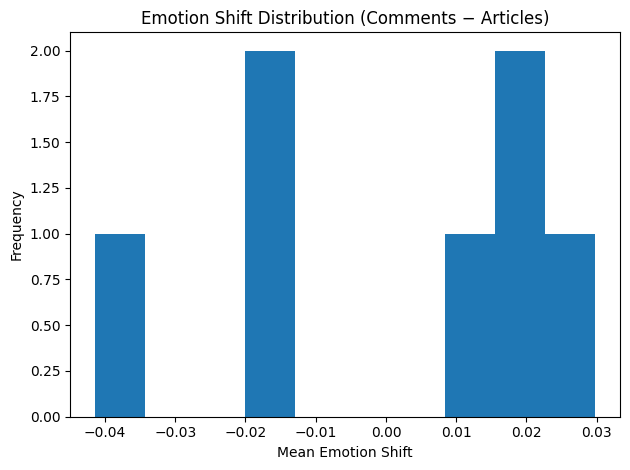

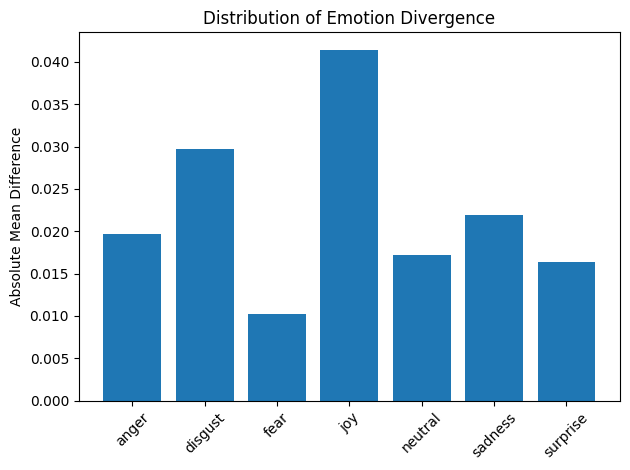

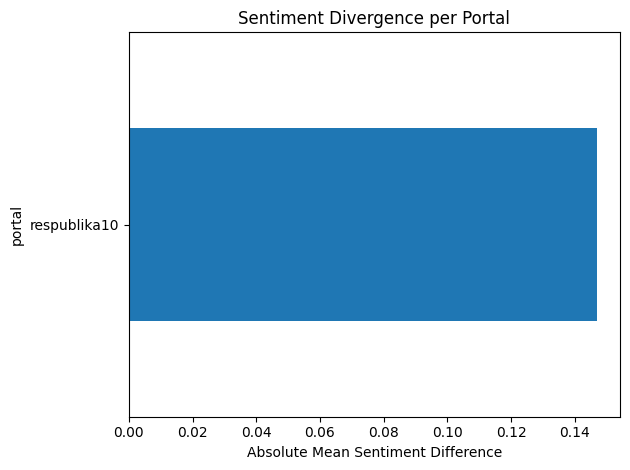

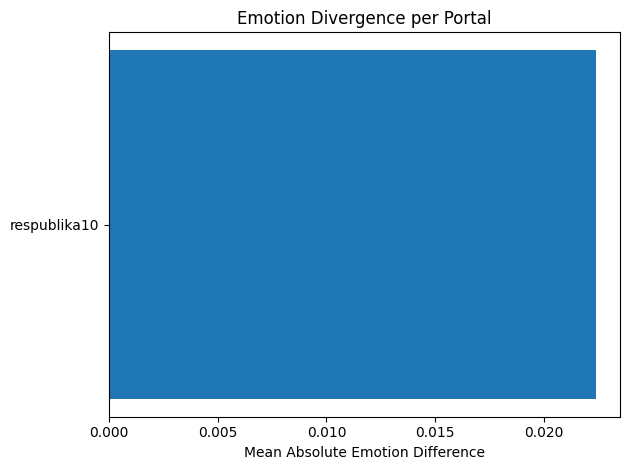

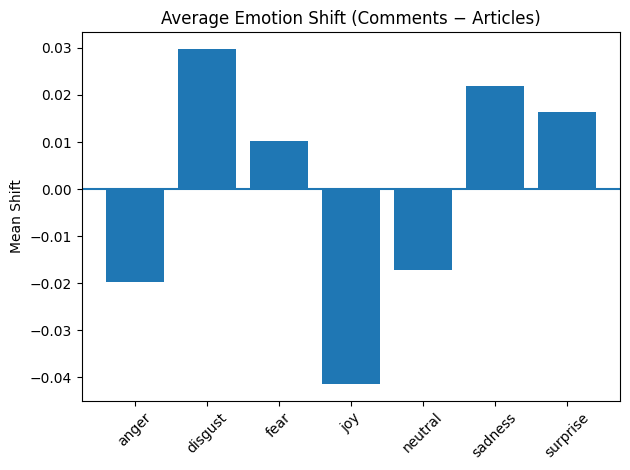

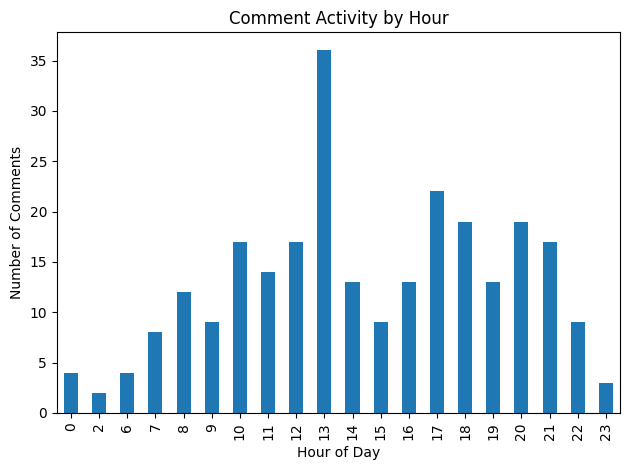

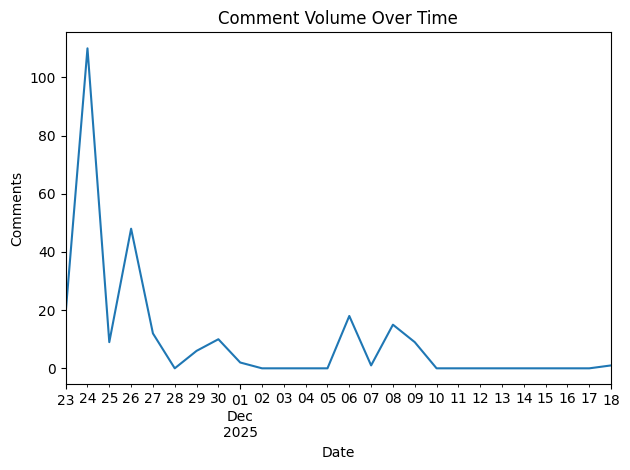

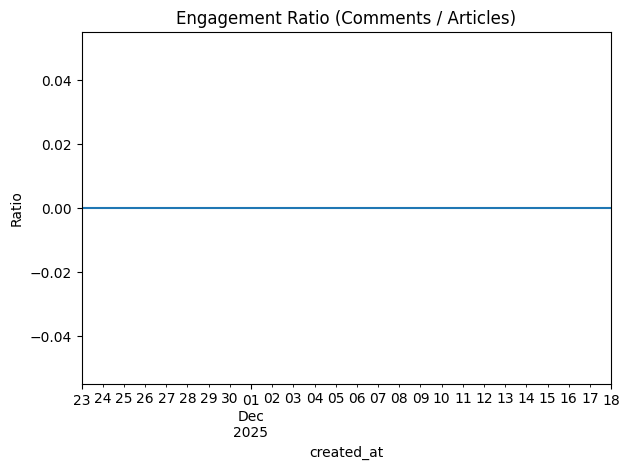

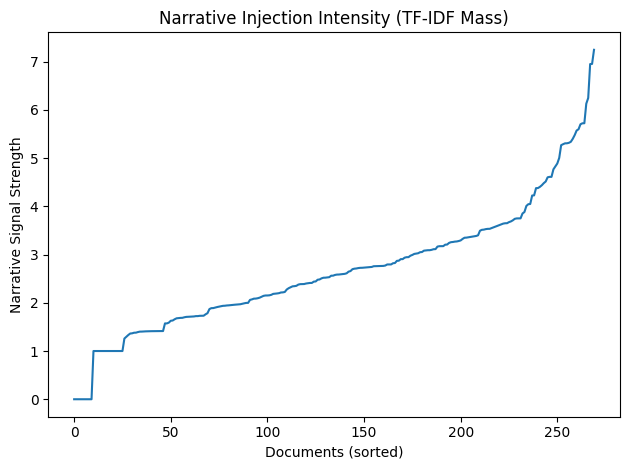

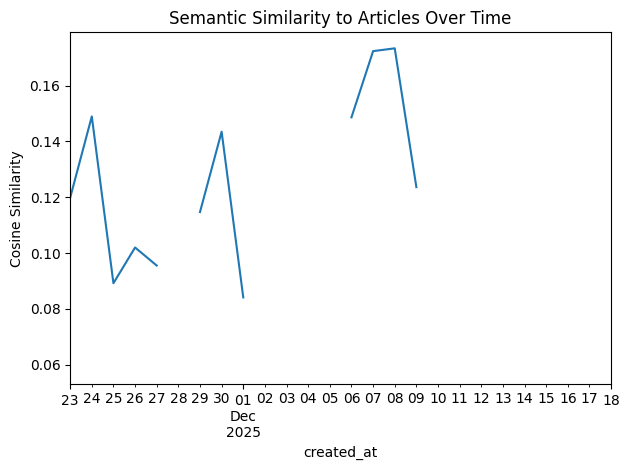


Wilcoxon + Cliff’s Delta (Article vs Comment):


,emotion,wilcoxon_p,cliffs_delta
5,sadness,0.064453,-0.56
4,neutral,0.083984,0.48
1,disgust,0.232422,-0.28
2,fear,0.322266,-0.18
0,anger,0.375000,0.32
3,joy,0.492188,0.26
6,surprise,0.492188,0.38


ValueError: Need at least two groups in stats.kruskal()

In [37]:
# ============================================================
# CONFERENCE-READY ANALYTICS & VISUALIZATIONS
# Assumes `data` already exists from your pipeline
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, kruskal
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# ------------------------------------------------------------
# BASIC SETUP
# ------------------------------------------------------------
emotion_cols = [c for c in data.columns if c.startswith("emotion_")]
emotions = [c.replace("emotion_", "") for c in emotion_cols]

articles = data[data["content_type"] == "article"]
comments = data[data["content_type"] == "comment"]

# ------------------------------------------------------------
# HELPER: CLIFF'S DELTA
# ------------------------------------------------------------
def cliffs_delta(x, y):
    x, y = np.array(x), np.array(y)
    nx, ny = len(x), len(y)
    gt = sum(i > j for i in x for j in y)
    lt = sum(i < j for i in x for j in y)
    return (gt - lt) / (nx * ny)

# ============================================================
# 0) EMOTION SHIFT DISTRIBUTION
# ============================================================

emotion_shift_dist = {
    emo: comments[emo].mean() - articles[emo].mean()
    for emo in emotion_cols
}

plt.figure()
plt.hist(emotion_shift_dist.values(), bins=10)
plt.title("Emotion Shift Distribution (Comments − Articles)")
plt.xlabel("Mean Emotion Shift")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ============================================================
# 1) DISTRIBUTION OF EMOTION DIVERGENCE
# ============================================================

emotion_divergence = {
    emo.replace("emotion_", ""):
    abs(comments[emo].mean() - articles[emo].mean())
    for emo in emotion_cols
}

plt.figure()
plt.bar(emotion_divergence.keys(), emotion_divergence.values())
plt.title("Distribution of Emotion Divergence")
plt.ylabel("Absolute Mean Difference")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 2) SENTIMENT DIVERGENCE PER PORTAL
# ============================================================

sent_div = (
    data.groupby(["portal", "content_type"])["sentiment_score"]
    .mean()
    .unstack()
    .dropna()
)

sent_div["sentiment_divergence"] = abs(
    sent_div["comment"] - sent_div["article"]
)

plt.figure()
sent_div["sentiment_divergence"].sort_values().plot(kind="barh")
plt.title("Sentiment Divergence per Portal")
plt.xlabel("Absolute Mean Sentiment Difference")
plt.tight_layout()
plt.show()

# ============================================================
# 3) EMOTION DIVERGENCE PER PORTAL
# ============================================================

portal_emo_div = []

for portal, dfp in data.groupby("portal"):
    a = dfp[dfp["content_type"] == "article"]
    c = dfp[dfp["content_type"] == "comment"]
    if len(a) == 0 or len(c) == 0:
        continue

    div = np.mean([abs(c[e].mean() - a[e].mean()) for e in emotion_cols])
    portal_emo_div.append((portal, div))

portal_emo_div = pd.DataFrame(
    portal_emo_div, columns=["portal", "emotion_divergence"]
).sort_values("emotion_divergence")

plt.figure()
plt.barh(portal_emo_div["portal"], portal_emo_div["emotion_divergence"])
plt.title("Emotion Divergence per Portal")
plt.xlabel("Mean Absolute Emotion Difference")
plt.tight_layout()
plt.show()

# ============================================================
# 4) AVERAGE EMOTION SHIFT (ALL EMOTIONS)
# ============================================================

plt.figure()
plt.bar(
    [e.replace("emotion_", "") for e in emotion_cols],
    [emotion_shift_dist[e] for e in emotion_cols]
)
plt.axhline(0)
plt.title("Average Emotion Shift (Comments − Articles)")
plt.ylabel("Mean Shift")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 5–7) TEMPORAL ANALYSIS (IF TIMESTAMP EXISTS)
# ============================================================

time_col = None
for c in ["created_at", "timestamp", "date", "datetime"]:
    if c in data.columns:
        time_col = c
        break

if time_col:
    data[time_col] = pd.to_datetime(data[time_col], errors="coerce")
    comments_t = data[data["content_type"] == "comment"].dropna(subset=[time_col])

    # 5) Comment activity by hour
    comments_t["hour"] = comments_t[time_col].dt.hour
    plt.figure()
    comments_t["hour"].value_counts().sort_index().plot(kind="bar")
    plt.title("Comment Activity by Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel("Number of Comments")
    plt.tight_layout()
    plt.show()

    # 6) Comment volume over time
    daily_comments = comments_t.set_index(time_col).resample("D").size()
    plt.figure()
    daily_comments.plot()
    plt.title("Comment Volume Over Time")
    plt.xlabel("Date")
    plt.ylabel("Comments")
    plt.tight_layout()
    plt.show()

    # 7) Engagement ratio over time
    articles_t = data[data["content_type"] == "article"].dropna(subset=[time_col])
    daily_articles = articles_t.set_index(time_col).resample("D").size()

    engagement_ratio = (daily_comments / daily_articles).replace([np.inf, np.nan], 0)
    plt.figure()
    engagement_ratio.plot()
    plt.title("Engagement Ratio (Comments / Articles)")
    plt.ylabel("Ratio")
    plt.tight_layout()
    plt.show()

# ============================================================
# 8) NARRATIVE INJECTION (TF-IDF CLUSTER PROXY)
# ============================================================

vectorizer = TfidfVectorizer(max_features=500, stop_words="english")
X = vectorizer.fit_transform(data["text"])

plt.figure()
plt.plot(np.sort(X.sum(axis=1).A1))
plt.title("Narrative Injection Intensity (TF-IDF Mass)")
plt.xlabel("Documents (sorted)")
plt.ylabel("Narrative Signal Strength")
plt.tight_layout()
plt.show()

# ============================================================
# 9) SEMANTIC SIMILARITY TO ARTICLE OVER TIME
# ============================================================

if time_col and len(articles) > 0:
    # article_vec = vectorizer.transform(articles["text"]).mean(axis=0)
    # comment_vecs = vectorizer.transform(comments["text"])
    # sims = cosine_similarity(comment_vecs, article_vec)
    
    article_vec = vectorizer.transform(articles["text"]).mean(axis=0)
    article_vec = np.asarray(article_vec)          # FIX: matrix → ndarray
    article_vec = article_vec.reshape(1, -1)       # ensure 2D
    
    comment_vecs = vectorizer.transform(comments["text"])
    sims = cosine_similarity(comment_vecs, article_vec)


    comments_sim = comments.copy()
    comments_sim["semantic_similarity"] = sims.flatten()

    sim_ts = comments_sim.set_index(time_col)["semantic_similarity"].resample("D").mean()

    plt.figure()
    sim_ts.plot()
    plt.title("Semantic Similarity to Articles Over Time")
    plt.ylabel("Cosine Similarity")
    plt.tight_layout()
    plt.show()

# ============================================================
# 10) STATISTICAL VALIDATION OF EMOTION SHIFTS
# ============================================================

stats = []

for emo in emotion_cols:
    a = articles[emo].dropna()
    c = comments[emo].dropna()
    m = min(len(a), len(c))
    if m < 10:
        continue

    a, c = a.iloc[:m], c.iloc[:m]
    stats.append({
        "emotion": emo.replace("emotion_", ""),
        "wilcoxon_p": wilcoxon(a, c).pvalue,
        "cliffs_delta": cliffs_delta(a, c)
    })

stats_df = pd.DataFrame(stats).sort_values("wilcoxon_p")
print("\nWilcoxon + Cliff’s Delta (Article vs Comment):")
display(stats_df)

kw_stat, kw_p = kruskal(*[
    data[data["portal"] == p]["sentiment_score"].dropna()
    for p in data["portal"].unique()
])

print(f"Kruskal–Wallis Sentiment Across Portals: p = {kw_p:.4e}")

# ============================================================
# UNIFIED INFLUENCE ALERT SCORE (UIAS)
# ============================================================

uias = (
    (sent_div["sentiment_divergence"] - sent_div["sentiment_divergence"].mean()) /
    sent_div["sentiment_divergence"].std()
).add(
    (portal_emo_div.set_index("portal")["emotion_divergence"] -
     portal_emo_div["emotion_divergence"].mean()) /
    portal_emo_div["emotion_divergence"].std(),
    fill_value=0
)

plt.figure()
uias.sort_values().plot(kind="barh")
plt.title("Unified Influence Alert Score (UIAS)")
plt.xlabel("Normalized Influence Score")
plt.tight_layout()
plt.show()


In [ ]:
# Semantic Drift Over Time (Narrative Injection)
# Narrative Injection (Narrative Clusters)
# Semantic Similarity & Narrative Drift
# Narrative Cluster Size Distribution

# TMP